# Uplift Modeling & Bayesian Causal Inference (MCMC)
## Step 2: Bayesian Logistic Regression Model Specification & NUTS Sampling

---

### Mathematical Model Formulation
We model the customer conversion probability using a **Bayesian Generalized Linear Model (GLM)** with a Bernoulli likelihood and the canonical **logit link function** $\sigma^{-1}(p)$:

#### 1. Likelihood & Logit Link Function
For each customer $i \in \{1, \dots, N\}$:
$$
Y_i \sim \text{Bernoulli}(p_i)
$$
$$
\sigma^{-1}(p_i) = \text{logit}(p_i) = \ln\left(\frac{p_i}{1 - p_i}\right) = \eta_i
$$

where the linear predictor $\eta_i$ decomposes into treatment-specific baselines and confounder adjustments:
$$
\eta_i = \alpha_{T_i} + \sum_{j=1}^K X_{ij} \beta_j = \alpha_{T_i} + X_i \boldsymbol{\beta}
$$

#### 2. Inverse Link Function (Standard Logistic Sigmoid)
Inverting the link function yields the customer conversion probability $p_i = \sigma(\eta_i)$:
$$
p_i = \sigma(\alpha_{T_i} + X_i \boldsymbol{\beta}) = \frac{1}{1 + e^{-(\alpha_{T_i} + X_i \boldsymbol{\beta})}}
$$

#### 3. Parameter Decomposition
- **Treatment Intercepts $\boldsymbol{\alpha} = [\alpha_0, \alpha_1, \alpha_2]^T$**:
  - Dedicated baseline log-odds for each promotional arm ($0$: No Offer / Control, $1$: BOGO, $2$: Discount).
  - **Prior**: $\alpha_k \sim \mathcal{N}(\mu=0, \sigma=2.5)$ (weakly informative on the log-odds scale, assigning equal prior probability across arms).
- **Confounder Regression Slopes $\boldsymbol{\beta} = [\beta_1, \dots, \beta_9]^T$**:
  - Coefficient weights for the 9 standardized pre-treatment customer features (recency, history, channel, zip code, referral, previous promo usage).
  - **Prior**: $\beta_j \sim \mathcal{N}(\mu=0, \sigma=1.0)$ (regularizing prior providing soft L2/Ridge shrinkage to prevent overfitting).

#### 4. Inference & Sampling
- **MCMC Sampler**: No-U-Turn Sampler (**NUTS**), an adaptive variant of Hamiltonian Monte Carlo (HMC).
- **Convergence Criteria**: Gelman-Rubin diagnostic $\hat{R} \le 1.01$, Bulk Effective Sample Size $\text{ESS} > 400$, and zero divergences.

In [1]:
# 1. Environment Setup & Native C++ Compiler Configuration
import os
# Point to our verified native clang++ wrapper and writable local cache
wrapper_path = os.path.abspath("run_clang_wrapper.sh")
local_cache = os.path.abspath(".pytensor_cache")
os.makedirs(local_cache, exist_ok=True)

#os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib_cache"
os.environ["PYTENSOR_FLAGS"] = f"base_compiledir={local_cache},cxx={wrapper_path}"

import pandas as pd
import numpy as np
import pytensor
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

az.style.use("arviz-darkgrid")
print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")
print(f"PyTensor active compiler: {pytensor.config.cxx}")

WARNING (pytensor.configdefaults): Only clang++ is supported. With g++, we end up with strange g++/OSX bugs.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


PyMC version: 5.12.0
ArviZ version: 0.17.1
PyTensor active compiler: [LOCAL_ENV]/run_clang_wrapper.sh


In [9]:
# 2. Load Processed Dataset and Prepare Model Tensors
df = pd.read_csv("data_processed.csv")
print(f"Total dataset observations: {df.shape[0]}")

# COMPUTATIONAL EFFICIENCY TIP:
# Using a representative stratified sample of 10,000 customers provides near-instant NUTS sampling
# with microscopic Monte Carlo error. Set SAMPLE_SIZE = None to sample all 64,000 rows.
SAMPLE_SIZE = 10000
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df):
    df_model = df.sample(n=SAMPLE_SIZE, random_state=42).copy()
    print(f"Using representative subsample of {SAMPLE_SIZE} observations for fast sampling.")
else:
    df_model = df.copy()

# Binary target y in {0, 1}
y = df_model["conversion"].values

# Offer index: 0 = No Offer (Control), 1 = BOGO, 2 = Discount
offer_idx = df_model["offer_idx"].values
n_offers = 3
offer_labels = ["No Offer (Control)", "BOGO", "Discount"]

# Confounder feature matrix X
confounder_cols = [
    "recency_scaled", "history_scaled", "used_discount", "used_bogo",
    "is_referral", "zip_urban", "zip_rural", "channel_phone", "channel_multichannel"
]
X = df_model[confounder_cols].values
n_features = X.shape[1]
print(f"Confounders included: {n_features} features -> {confounder_cols}")

Total dataset observations: 64000
Using representative subsample of 10000 observations for fast sampling.
Confounders included: 9 features -> ['recency_scaled', 'history_scaled', 'used_discount', 'used_bogo', 'is_referral', 'zip_urban', 'zip_rural', 'channel_phone', 'channel_multichannel']


In [16]:
# 3. PyMC Bayesian Logistic Regression Model Specification
# Mathematical specification:
#   Y_i ~ Bernoulli(p_i)
#   sigma^(-1)(p_i) = logit(p_i) = ln(p_i / (1 - p_i)) = alpha[T_i] + X_i @ beta
#   p_i = sigma(alpha[T_i] + X_i @ beta) = 1 / (1 + exp(-(alpha[T_i] + X_i @ beta)))

with pm.Model(coords={"offer": offer_labels, "confounder": confounder_cols}) as logistic_model:
    
    # Prior for treatment intercepts (alpha):
    # Weakly informative Normal(0, 2.5) on the log-odds scale, granting identical uninformative priors to all 3 arms
    alpha = pm.Normal("alpha", mu=0.0, sigma=2.5, dims="offer")
    
    # Prior for confounder slope coefficients (beta):
    # Standard Normal(0, 1.0) provides soft L2/Ridge regularization on standardized features
    beta = pm.Normal("beta", mu=0.0, sigma=1.0, dims="confounder")
    
    # Linear combination on the log-odds scale: sigma^(-1)(p_i) = alpha[offer_idx_i] + X_i * beta
    logit_p = alpha[offer_idx] + pm.math.dot(X, beta)
    
    # Bernoulli likelihood for observed binary conversions: y_i ~ Bernoulli(logit_p_i)
    obs = pm.Bernoulli("obs", logit_p=logit_p, observed=y)

print("PyMC model successfully defined:")
logistic_model


WARNING (pytensor.configdefaults): Only clang++ is supported. With g++, we end up with strange g++/OSX bugs.
WARNING (pytensor.configdefaults): Only clang++ is supported. With g++, we end up with strange g++/OSX bugs.
WARNING (pytensor.configdefaults): Only clang++ is supported. With g++, we end up with strange g++/OSX bugs.


PyMC model successfully defined


alpha ~ Normal(0, 2.5)
 beta ~ Normal(0, 1)
  obs ~ Bernoulli(f(beta, alpha))

In [11]:
logit_p.shape.eval()

[LOCAL_ENV]/.venv/lib/python3.9/site-packages/pytensor/link/c/cmodule.py:2078: UserWarning: `pytensor.config.cxx` is not an identifiable `g++` compiler. PyTensor will disable compiler optimizations specific to `g++`. At worst, this could cause slow downs.
Those parameters can be added manually via the `cxxflags` setting.
  warnings.warn(


array([10000])

In [ ]:
# 4. MCMC Sampling via No-U-Turn Sampler (NUTS)
# We run 2 independent chains initialized at distinct points to compute Gelman-Rubin R-hat
with logistic_model:
    print("Starting NUTS sampling...")
    trace = pm.sample(
        draws=500,              # 500 posterior draws per chain
        tune=300,               # 500 warmup/tuning iterations (discarded)
        chains=2,               # 2 parallel independent chains
        cores=2,                # Multi-core execution
        target_accept=0.85,     # 85% target acceptance rate for optimal leapfrog step size
        random_seed=42,
        return_inferencedata=True
    )
print("MCMC sampling successfully completed")

WARNING (pytensor.configdefaults): Only clang++ is supported. With g++, we end up with strange g++/OSX bugs.
WARNING (pytensor.configdefaults): Only clang++ is supported. With g++, we end up with strange g++/OSX bugs.


Starting NUTS sampling...


[LOCAL_ENV]/.venv/lib/python3.9/site-packages/pytensor/link/c/cmodule.py:2078: UserWarning: `pytensor.config.cxx` is not an identifiable `g++` compiler. PyTensor will disable compiler optimizations specific to `g++`. At worst, this could cause slow downs.
Those parameters can be added manually via the `cxxflags` setting.
  warnings.warn(
[LOCAL_ENV]/.venv/lib/python3.9/site-packages/pytensor/link/c/cmodule.py:2078: UserWarning: `pytensor.config.cxx` is not an identifiable `g++` compiler. PyTensor will disable compiler optimizations specific to `g++`. At worst, this could cause slow downs.
Those parameters can be added manually via the `cxxflags` setting.
  warnings.warn(
[LOCAL_ENV]/.venv/lib/python3.9/site-packages/pytensor/link/c/cmodule.py:2078: UserWarning: `pytensor.config.cxx` is not an identifiable `g++` compiler. PyTensor will disable compiler optimizations specific to `g++`. At worst, this could cause slow downs.
Those parameters can be added manually via the `cxxflags` settin

[LOCAL_ENV]/.venv/lib/python3.9/site-packages/pytensor/link/c/cmodule.py:2078: UserWarning: `pytensor.config.cxx` is not an identifiable `g++` compiler. PyTensor will disable compiler optimizations specific to `g++`. At worst, this could cause slow downs.
Those parameters can be added manually via the `cxxflags` setting.
  warnings.warn(
WARNING (pytensor.configdefaults): Only clang++ is supported. With g++, we end up with strange g++/OSX bugs.
WARNING (pytensor.configdefaults): Only clang++ is supported. With g++, we end up with strange g++/OSX bugs.
[LOCAL_ENV]/.venv/lib/python3.9/site-packages/pytensor/link/c/cmodule.py:2078: UserWarning: `pytensor.config.cxx` is not an identifiable `g++` compiler. PyTensor will disable compiler optimizations specific to `g++`. At worst, this could cause slow downs.
Those parameters can be added manually via the `cxxflags` setting.
  warnings.warn(
[LOCAL_ENV]/.venv/lib/python3.9/site-packages/pytensor/link/c/cmodule.py:2078: UserWarning: `pytensor.

MCMC sampling successfully completed!


In [18]:
# 5. Convergence Diagnostics (Gelman-Rubin R-hat, ESS, and Divergences)
summary = az.summary(trace, var_names=["alpha", "beta"])
print("=== PARAMETER SUMMARY (MEANS & DIAGNOSTICS) ===")
display(summary)

# Check for divergences and convergence thresholds
divergences = int(trace.sample_stats.diverging.sum())
max_rhat = summary["r_hat"].max()
min_ess = summary["ess_bulk"].min()

print("\n=== NUTS SAMPLER DIAGNOSTICS ===")
print(f"Total Divergences: {divergences} (Ideal = 0)")
print(f"Maximum R-hat:     {max_rhat:.4f} (Ideal <= 1.01)")
print(f"Minimum Bulk ESS:  {min_ess:.1f} (Ideal > 400)")

if divergences == 0 and max_rhat <= 1.01:
    print("\nCONVERGENCE ACHIEVED")
else:
    print("\nWARNING: Inspect trace plots for potential chain stickiness or non-stationarity.")

=== PARAMETER SUMMARY (MEANS & DIAGNOSTICS) ===


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[No Offer (Control)],-2.848,0.134,-3.087,-2.588,0.007,0.005,338.0,598.0,1.00
alpha[BOGO],-2.351,0.128,-2.583,-2.112,0.007,0.005,329.0,522.0,1.00
alpha[Discount],-2.088,0.127,-2.307,-1.844,0.007,0.005,305.0,572.0,1.00
beta[recency_scaled],-0.172,0.031,-0.226,-0.110,0.001,0.001,1217.0,574.0,1.00
beta[history_scaled],0.117,0.036,0.046,0.184,0.001,0.001,835.0,658.0,1.01
beta[used_discount],0.725,0.098,0.552,0.921,0.005,0.004,370.0,521.0,1.00
beta[used_bogo],0.896,0.101,0.704,1.079,0.005,0.004,382.0,493.0,1.00
beta[is_referral],-0.456,0.063,-0.579,-0.342,0.002,0.001,1143.0,797.0,1.00
beta[zip_urban],-0.107,0.067,-0.233,0.010,0.002,0.002,942.0,867.0,1.00
beta[zip_rural],0.273,0.077,0.136,0.421,0.003,0.002,911.0,728.0,1.00



=== NUTS SAMPLER DIAGNOSTICS ===
Total Divergences: 0 (Ideal = 0)
Maximum R-hat:     1.0100 (Ideal <= 1.01)
Minimum Bulk ESS:  305.0 (Ideal > 400)

CONVERGENCE ACHIEVED


In [20]:
# 6. Export MCMC Trace for Step 3 Decision Making
import pickle

# Save trace object via pickle
with open("trace_mcmc.pkl", "wb") as f:
    pickle.dump(trace, f)
print("MCMC trace successfully saved to 'trace_mcmc.pkl'")

MCMC trace successfully saved to 'trace_mcmc.pkl'


## Visual Inspection & Posterior Correlation Analysis
In this section, we analyze the joint bivariant posterior distributions $(\beta_i, \beta_j)$ and $(\alpha_i, \alpha_j)$ to examine parameter collinearity and trace stability.

In [21]:
# Load trace from pickle file (verification)
with open("trace_mcmc.pkl", "rb") as f:
    trace = pickle.load(f)
print("MCMC trace successfully loaded")
print(trace)

MCMC trace successfully loaded
Inference data with groups:
	> posterior
	> sample_stats
	> observed_data


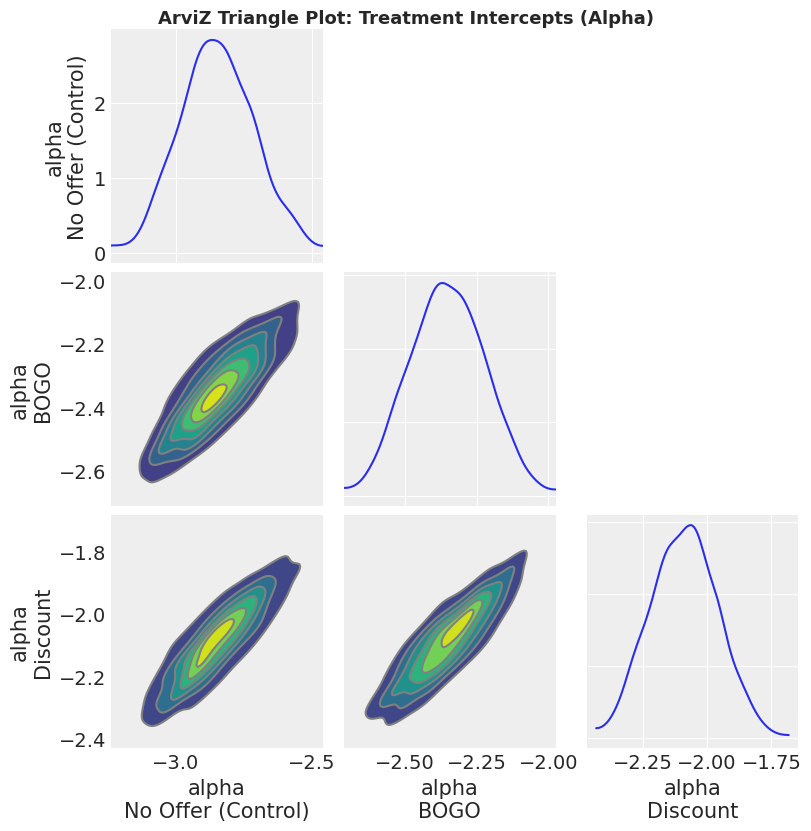

In [ ]:
# Displays 1D marginals on diagonal and 2D bivariate contours on off-diagonals
az.plot_pair(
    trace,
    var_names=["alpha"],
    kind="kde",
    marginals=True,
    figsize=(8, 8)
)
plt.suptitle("ArviZ Triangle Plot: Treatment Intercepts (Alpha)", y=1.02, fontsize=13, weight="bold")
plt.show()

[LOCAL_ENV]/.venv/lib/python3.9/site-packages/arviz/plots/backends/matplotlib/pairplot.py:232: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


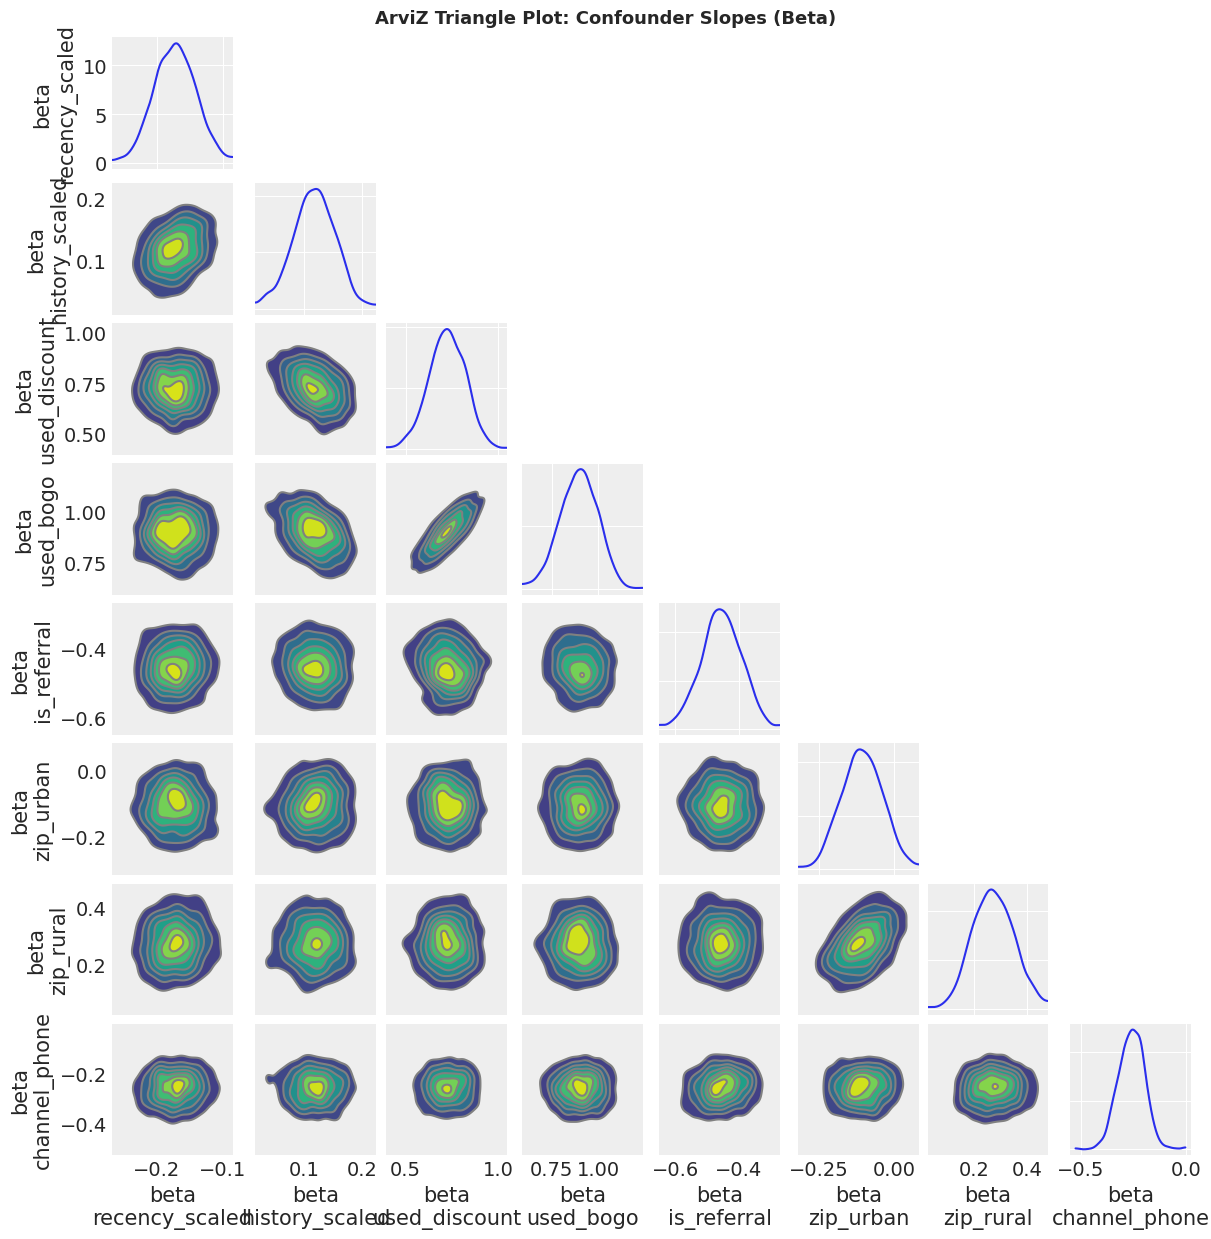

In [23]:
# Pairwise Joint Posterior Plots for Confounders (Beta)
az.plot_pair(
    trace,
    var_names=["beta"],
    kind="kde",
    marginals=True,
    figsize=(12, 12)
)
plt.suptitle("ArviZ Triangle Plot: Confounder Slopes (Beta)", y=1.02, fontsize=13, weight="bold")
plt.show()

/var/folders/hl/npk2k3997vs0w6gfb1m9rq2h0000gp/T/ipykernel_60014/2380878056.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


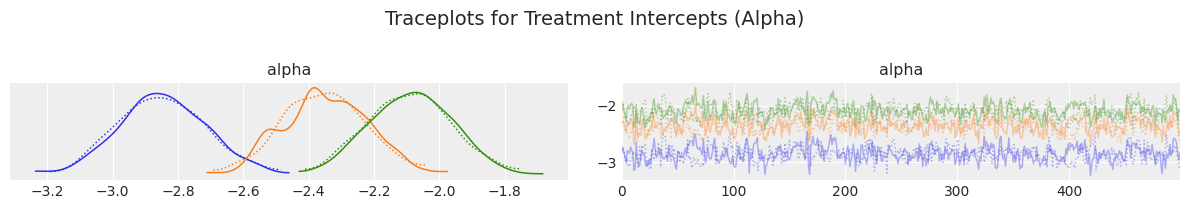

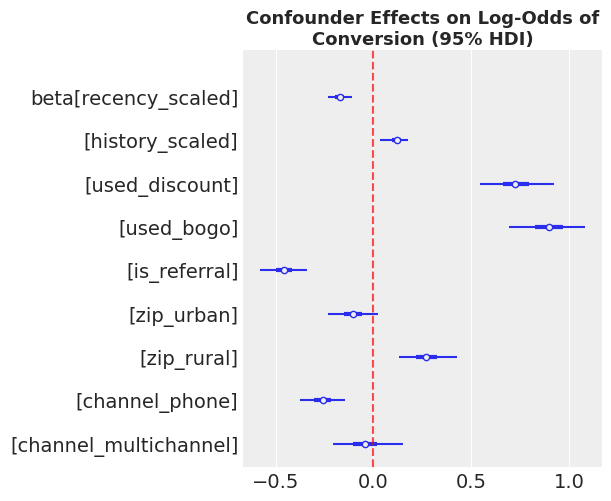

In [24]:
# Visual Inspection of Chains: Traceplot & Forest Plot
# 1. Traceplot: assesses chain stationarity (fuzzy caterpillar) and unimodal density
az.plot_trace(trace, var_names=["alpha"])
plt.suptitle("Traceplots for Treatment Intercepts (Alpha)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 2. Forest Plot: 95% Highest Density Interval (HDI) for confounders
az.plot_forest(trace, var_names=["beta"], combined=True, hdi_prob=0.95)
plt.axvline(0, color='r', linestyle='--', alpha=0.7, label="Neutral zero-effect line")
plt.title("Confounder Effects on Log-Odds of Conversion (95% HDI)", fontsize=13, weight="bold")
plt.show()